In [1]:
from pathlib import Path

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt

from nbtools import auto_plot_style
from nbtools import normhist, normhist2d

In [2]:
auto_plot_style()

In [3]:
path3_20 = Path("../data/pcolina/3x3/0.20/reco.h5")
path3_65 = Path("../data/pcolina/3x3/0.65/reco.h5")
path6_50 = Path("../data/pcolina/6x6/reco.h5")
path3_20.exists(), path3_65.exists(), path6_50.exists()

(True, True, True)

In [4]:
data3_20 = pd.read_hdf(path3_20)
data3_65 = pd.read_hdf(path3_65)
data6_50 = pd.read_hdf(path6_50)

In [5]:
rbins     = np.linspace(  0, 16, 81)
xybins    = np.linspace(-16, 16, 81)
drbins_bb = np.linspace(  0, 12, 81)
drbins_nn = np.linspace(  0, 3, 81)

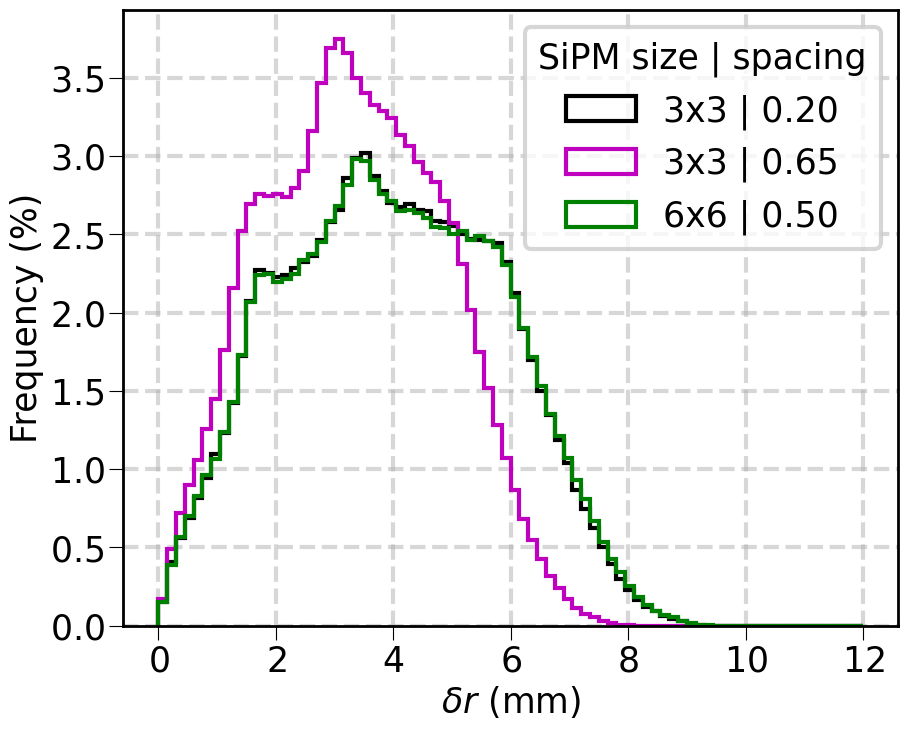

In [6]:
normhist(data3_20.dr_bb, drbins_bb, label="3x3 | 0.20")
normhist(data3_65.dr_bb, drbins_bb, label="3x3 | 0.65")
normhist(data6_50.dr_bb, drbins_bb, label="6x6 | 0.50")
plt.xlabel("$\delta r$ (mm)")
plt.ylabel("Frequency (%)")
plt.legend(title="SiPM size | spacing")
plt.grid()

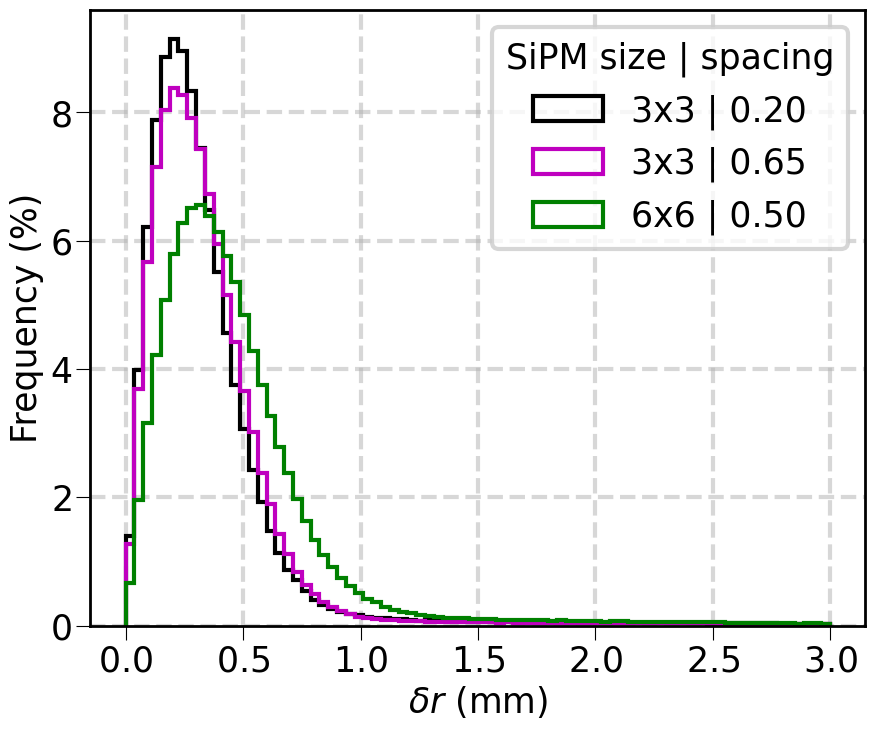

In [7]:
normhist(data3_20.dr_nn, drbins_nn, label="3x3 | 0.20")
normhist(data3_65.dr_nn, drbins_nn, label="3x3 | 0.65")
normhist(data6_50.dr_nn, drbins_nn, label="6x6 | 0.50")
plt.xlabel("$\delta r$ (mm)")
plt.ylabel("Frequency (%)")
plt.legend(title="SiPM size | spacing")
plt.grid()

In [9]:
def profile(df, n):
    binsize = 16 / n
    binid = df.r0 // binsize
    out   = df.groupby(binid).agg( bb_mean = pd.NamedAgg(column="dr_bb", aggfunc="mean")
                                 , bb_std  = pd.NamedAgg(column="dr_bb", aggfunc="std" )
                                 , nn_mean = pd.NamedAgg(column="dr_nn", aggfunc="mean")
                                 , nn_std  = pd.NamedAgg(column="dr_nn", aggfunc="std" )
                                 )
    out.insert(0, "ur0", binsize / 2)
    out.insert(0,  "r0", (out.index + 0.5) * binsize)
    return out.reset_index(drop=True)

In [10]:
profs3_20 = profile(data3_20, 26)
profs3_65 = profile(data3_65, 26)
profs6_50 = profile(data6_50, 26)

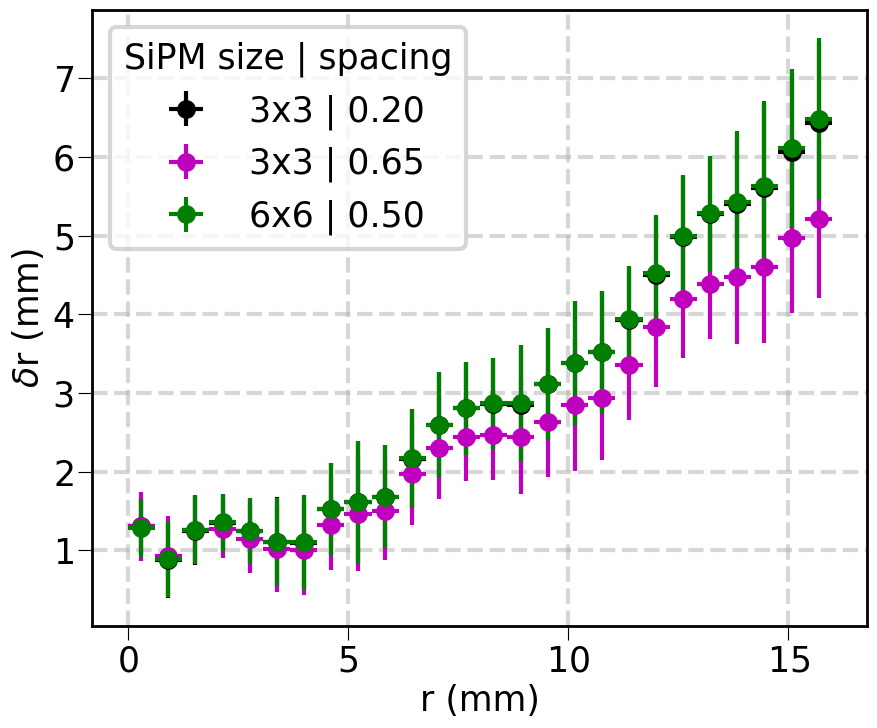

In [11]:
df=profs3_20;plt.errorbar(df.r0, df.bb_mean, df.bb_std, df.ur0, fmt=".", label="3x3 | 0.20")
df=profs3_65;plt.errorbar(df.r0, df.bb_mean, df.bb_std, df.ur0, fmt=".", label="3x3 | 0.65")
df=profs6_50;plt.errorbar(df.r0, df.bb_mean, df.bb_std, df.ur0, fmt=".", label="6x6 | 0.50")
plt.xlabel("r (mm)")
plt.ylabel("$\delta$r (mm)")
plt.legend(title="SiPM size | spacing")
plt.grid()

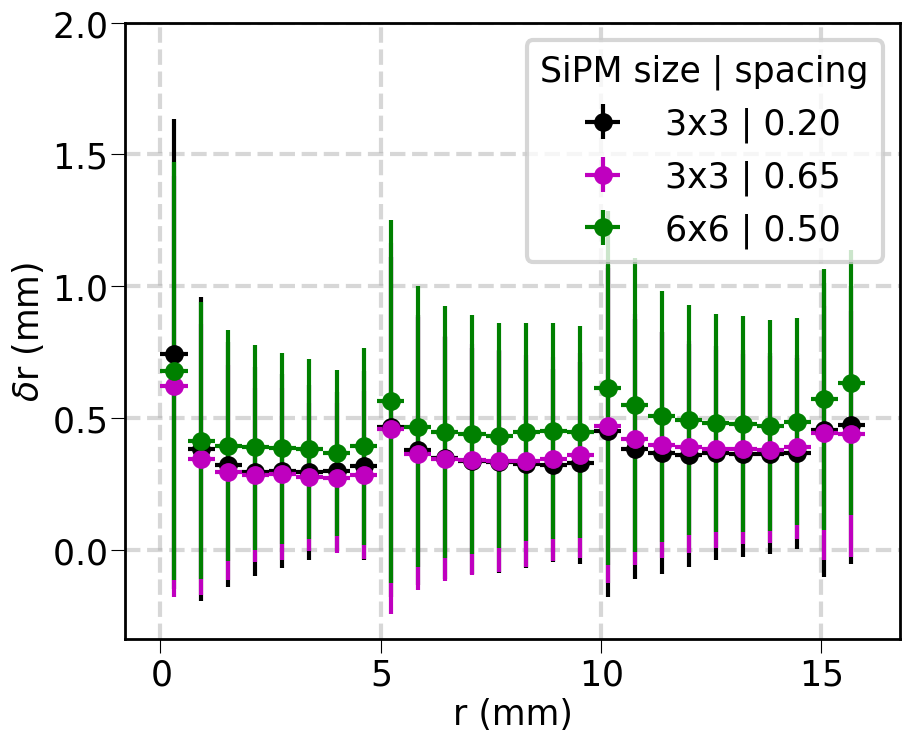

In [15]:
df=profs3_20;plt.errorbar(df.r0, df.nn_mean, df.nn_std, df.ur0, fmt=".", label="3x3 | 0.20")
df=profs3_65;plt.errorbar(df.r0, df.nn_mean, df.nn_std, df.ur0, fmt=".", label="3x3 | 0.65")
df=profs6_50;plt.errorbar(df.r0, df.nn_mean, df.nn_std, df.ur0, fmt=".", label="6x6 | 0.50")
plt.xlabel("r (mm)")
plt.ylabel("$\delta$r (mm)")
plt.legend(title="SiPM size | spacing")
plt.ylim(None, 2)
plt.grid()